<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/education.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Course completion & dropout — adoption case study

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 16 — Most AI failures are operating-model failures  
**Rows:** 1,727  ·  **Source file:** `education_enrollments.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/education_enrollments.csv"
LOCAL = "education_enrollments.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (1727, 12)


,enrollment_id,student_id,course_id,subject,modality,start_date,status,final_score,grade_band,certificate_earned,predicted_dropout_risk,risk_band
0,EN000001,ST00001,CR010,Machine Learning,Online live,46208,completed,52.7,At risk,False,35.8,Low
1,EN000002,ST00001,CR014,Data Visualization,Blended,46062,completed,65.7,Pass,True,53.6,Low
2,EN000003,ST00001,CR008,Data Ethics,Blended,46027,withdrawn,57.1,At risk,False,44.9,Low
3,EN000004,ST00002,CR001,AI Foundations,Self-paced,46098,completed,59.8,At risk,False,35.3,Very low
4,EN000005,ST00003,CR001,AI Foundations,Self-paced,46151,completed,53.4,At risk,False,39.9,Low


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
enrollment_id                 str
student_id                    str
course_id                     str
subject                       str
modality                      str
start_date                  int64
status                        str
final_score               float64
grade_band                    str
certificate_earned           bool
predicted_dropout_risk    float64
risk_band                     str

No missing values.


---
## Problem 1 · Easy — describe

What share of enrollments complete / are at risk / withdraw? What is the certificate-earned rate? Which modality completes best?

*Try it yourself first. The worked solution is below.*

In [3]:
print(f"Enrolments: {len(df):,}  Students: {df['student_id'].nunique():,}  Courses: {df['course_id'].nunique()}")
print("\nStatus:\n", df["status"].value_counts())
print(f"\nCertificate rate: {df['certificate_earned'].mean():.1%}")
print("\nBy modality:")
print(df.groupby("modality").agg(n=("status","size"),
                                 certificate_rate=("certificate_earned","mean"),
                                 mean_score=("final_score","mean")).round(3))

Enrolments: 1,727  Students: 850  Courses: 14

Status:
 status
completed      1303
active_risk     225
withdrawn       199
Name: count, dtype: int64

Certificate rate: 63.6%

By modality:
               n  certificate_rate  mean_score
modality                                      
Blended      399             0.662      66.120
In-person    354             0.641      66.335
Online live  548             0.631      65.792
Self-paced   426             0.613      65.898


---
## Problem 2 · Intermediate — build

Does predicted_dropout_risk actually track withdrawals? Which modality + subject combinations are riskiest? What early signal would let you intervene in week 2, not week 8?

*Try it yourself first. The worked solution is below.*

In [4]:
print("Completion by subject:")
print(df.groupby("subject").agg(n=("status","size"),
                                certificate_rate=("certificate_earned","mean"),
                                mean_score=("final_score","mean"))
        .sort_values("certificate_rate").round(3))
print("\nRisk band vs what actually happened:")
print(pd.crosstab(df["risk_band"], df["certificate_earned"], normalize="index").round(3))

Completion by subject:
                      n  certificate_rate  mean_score
subject                                              
Prompt Engineering  214             0.593      65.836
Data Visualization  230             0.609      64.437
AI Foundations      341             0.633      66.332
Machine Learning    164             0.634      66.737
Python              283             0.636      65.924
Statistics          225             0.640      66.183
Data Ethics         270             0.693      66.554

Risk band vs what actually happened:
certificate_earned  False  True 
risk_band                       
Low                 0.421  0.579
Medium              0.657  0.343
Very low            0.186  0.814


---
## Problem 3 · Advanced — judge

Design the adoption & intervention operating model: the trigger (risk threshold), the action (mentor minutes, deadline extension), the owner, and the metric. Tie it to Lesson 16 — a prediction is worthless without a workflow that acts on it.

*Try it yourself first. The worked solution is below.*

In [5]:
from sklearn.metrics import roc_auc_score
d = df.dropna(subset=["predicted_dropout_risk"]).copy()
dropped = (~d["certificate_earned"]).astype(int)
print(f"AUC of the shipped risk score: {roc_auc_score(dropped, d['predicted_dropout_risk']):.3f}")

print("\nIf you intervene on the top-risk decile, who do you actually reach?")
cut = d["predicted_dropout_risk"].quantile(.9)
top = d[d["predicted_dropout_risk"] >= cut]
print(f"  learners flagged: {len(top)}")
print(f"  of those, actually dropped: {(~top['certificate_earned']).mean():.1%}")
print(f"  share of ALL drop-outs captured: "
      f"{(~top['certificate_earned']).sum() / dropped.sum():.1%}")
print("""
The ethical design question
  A drop-out score should trigger SUPPORT, never a penalty, never a hidden
  filter on admission. Tell learners it exists, and give them a route to
  challenge it. Anything else converts a helpful model into a harmful one.
""")

AUC of the shipped risk score: 0.708

If you intervene on the top-risk decile, who do you actually reach?
  learners flagged: 174
  of those, actually dropped: 65.5%
  share of ALL drop-outs captured: 18.1%

The ethical design question
  A drop-out score should trigger SUPPORT, never a penalty, never a hidden
  filter on admission. Tell learners it exists, and give them a route to
  challenge it. Anything else converts a helpful model into a harmful one.



---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


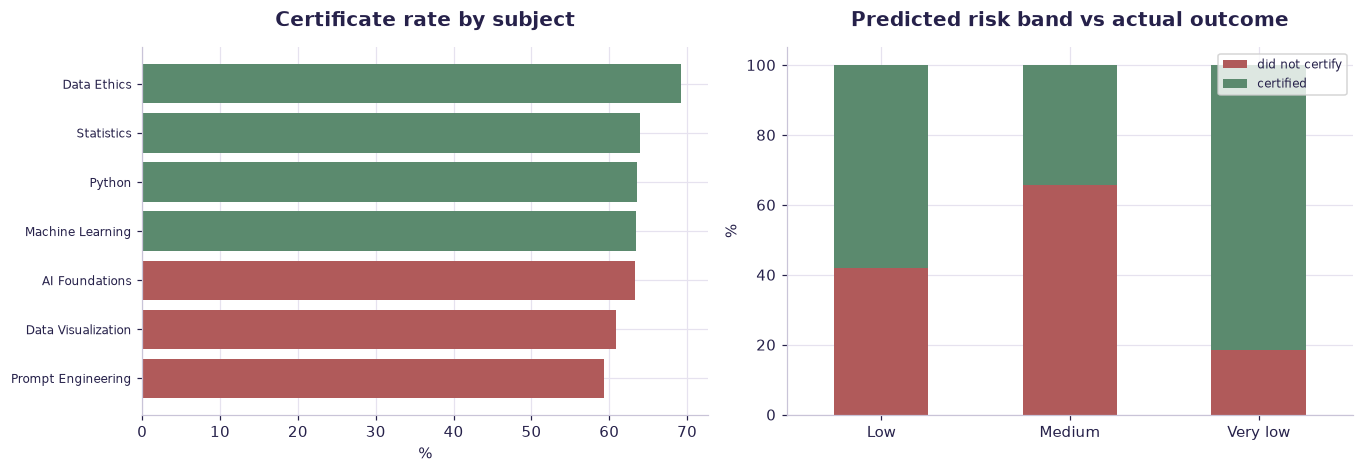

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
s = df.groupby("subject")["certificate_earned"].mean().mul(100).sort_values()
ax[0].barh(s.index, s.values, color=[DANGER if v < s.mean() else CORE for v in s])
ax[0].set_title("Certificate rate by subject"); ax[0].set_xlabel("%")
ax[0].tick_params(axis="y", labelsize=8)

t = pd.crosstab(df["risk_band"], df["certificate_earned"], normalize="index").mul(100)
t.plot(kind="bar", stacked=True, ax=ax[1], color=[DANGER, CORE], rot=0)
ax[1].set_title("Predicted risk band vs actual outcome"); ax[1].set_ylabel("%"); ax[1].set_xlabel("")
ax[1].legend(["did not certify", "certified"], fontsize=8)
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. 1,727 enrollments: 75% completed, 13% active-risk, 12% withdrawn; 63.6% earned a certificate
2. Completion by modality is close (Blended 79% best, Self-paced/Online-live 74%) — modality alone is not destiny
3. Meta-lesson: a dropout-risk score only creates value if an intervention (mentor time, deadline flex) is triggered and owned
4. Ties to Lesson 16: adoption is an engine — trigger, action, owner, metric — not a dashboard


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** Operating model canvas + adoption plan for one workflow.

---
*Applied AI Academy · appliedai.center*
